In [1]:
import numpy as np
import os
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
X_PCA_PATH = "/kaggle/input/gene-preprocess/saved_model/X_pca.npy"

OUTPUT_DIR = "/kaggle/working/"

In [3]:
X_pca = np.load(X_PCA_PATH)
print("X_pca shape:", X_pca.shape)

X_pca shape: (111, 10)


In [4]:
def compute_matrix(list_clusters):
    list_matrix = []
    for clusters in list_clusters:
        list_matrix.append(clusters_to_matrix(clusters))
    return combine_list_matrix(list_matrix)
    
def clusters_to_matrix(clusters):
    y_reshaped = np.expand_dims(clusters, axis=-1)
    matrix = (cdist(y_reshaped, y_reshaped, metric="cityblock")==0).astype('int')
    return matrix

def normalize_matrix(matrix):
    return matrix / matrix.diagonal()

def combine_list_matrix(list_matrix):
    matrix_size = len(list_matrix[0])

    result_matrix = np.zeros((matrix_size, matrix_size), dtype='float')

    for matrix in list_matrix:
        result_matrix += matrix

    return normalize_matrix(result_matrix)

In [5]:
def build_weighted_matrix(list_matrix, weights=None):
    list_matrix_copy = []
    for matrix in list_matrix:
        matrix_copy = matrix.copy()
        matrix_copy[matrix_copy == 0] = 1e-8
        list_matrix_copy.append(matrix_copy)
        
    if weights is not None:
        for i in range(len(list_matrix)):
            list_matrix_copy[i] *= weights[i]
    return combine_list_matrix(list_matrix_copy)

In [6]:
path = "/kaggle/input/kmeans/kmeans_ensemble/kmeans_ensemble_labels.npy"
kmeans_list_labels = np.load(path)

path = "/kaggle/input/agglomerative-clustering/agg_ensemble/agg_ensemble_labels.npy"
agg_list_labels = [np.load(path)]

path = "/kaggle/input/spectral-clustering/spectral_ensemble/spectral_ensemble_labels.npy"
spectral_list_labels = [np.load(path)]

In [7]:
matrix_kmeans = compute_matrix(kmeans_list_labels)
matrix_agg = compute_matrix(agg_list_labels)
matrix_spectral = compute_matrix(spectral_list_labels)

list_matrix = [
    matrix_kmeans,
    matrix_agg,
    matrix_spectral
]

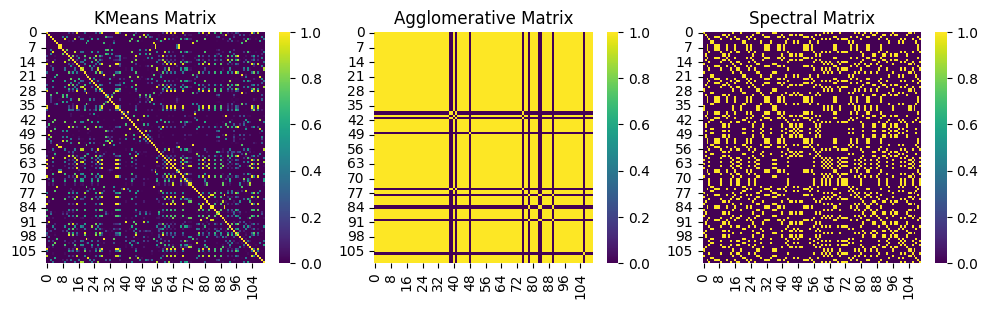

In [8]:
plt.figure(figsize=(12, 3))
plt.subplot(1,3,1)
sns.heatmap(matrix_kmeans, cmap='viridis')
plt.title("KMeans Matrix")


plt.subplot(1,3,2)
sns.heatmap(matrix_agg, cmap='viridis')
plt.title("Agglomerative Matrix")

plt.subplot(1,3,3)
sns.heatmap(matrix_spectral, cmap='viridis')
plt.title("Spectral Matrix")

plt.show()

In [9]:
def heatmap_ensemble(matrix):
    sns.heatmap(matrix, cmap='viridis')
    plt.title("Heatmap Similarity Matrix")
    plt.show()

In [10]:
def ensemble_result(matrix):
    k_range = range(2, 20)
    
    results = {
        'k': [],
        'silhouette': [],
        'labels': []
    }
    
    for k in k_range:
        spectral_ensemble = SpectralClustering(n_clusters=k, affinity="precomputed")
        
        labels = spectral_ensemble.fit_predict(matrix)
        score = silhouette_score(X_pca, labels)
        
        results['k'].append(k)
        results['silhouette'].append(score)
        results['labels'].append(labels)
    return results

def ensemble_with_k(matrix, k):
    spectral_ensemble = SpectralClustering(n_clusters=k, affinity="precomputed") 
    labels = spectral_ensemble.fit_predict(matrix)
    return labels

In [11]:
def silhouette_plot(results):
    plt.plot(results['k'], results['silhouette'], marker="o")
    plt.xlabel("k clusters")
    plt.ylabel("Silhouette score")
    plt.title("Silhouette score Ensemble")
    plt.grid(True)
    plt.show()

def scatter_cluster(X_pca, labels, k):
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
    plt.xlabel("PCA First Component")
    plt.ylabel("PCA Second Component")
    plt.title(f"CLustering Result k={k}")
    plt.grid(True)
    plt.show()

Kết hợp cả 3 mô hình

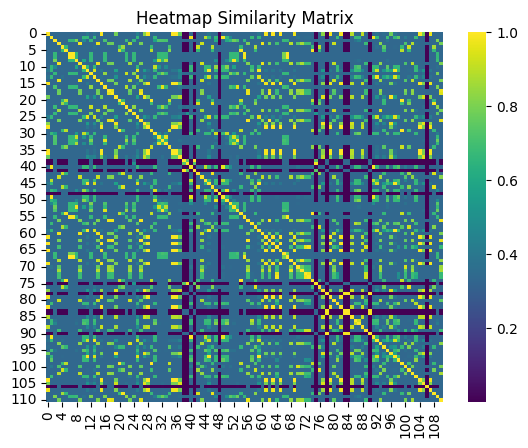

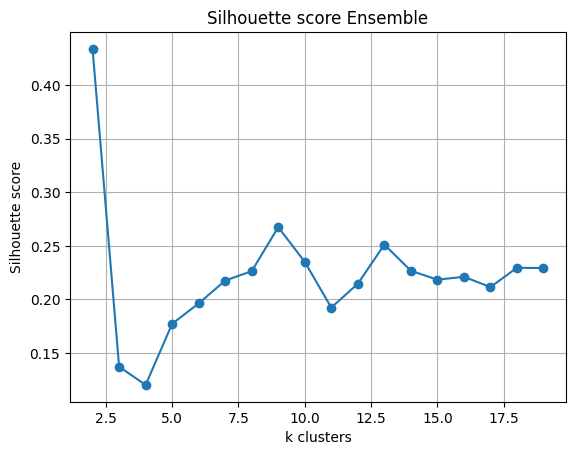

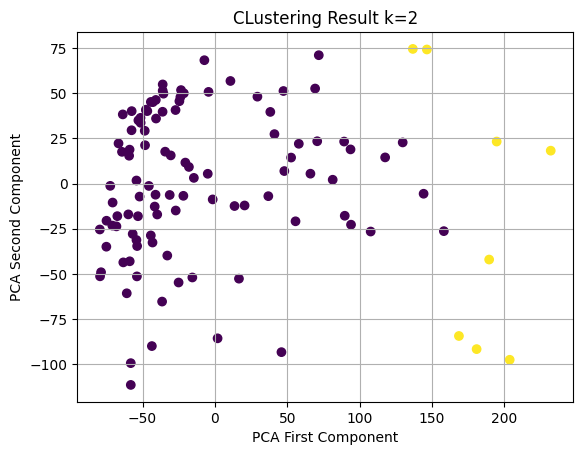

In [12]:
ensemble_matrix = build_weighted_matrix(list_matrix)

heatmap_ensemble(ensemble_matrix)
results = ensemble_result(ensemble_matrix)
silhouette_plot(results)

k=2
labels = ensemble_with_k(ensemble_matrix, k)
scatter_cluster(X_pca, labels, k)

Kết hợp kmeans và agglomerative

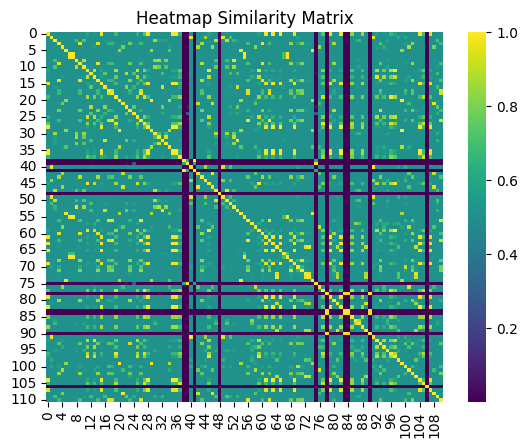

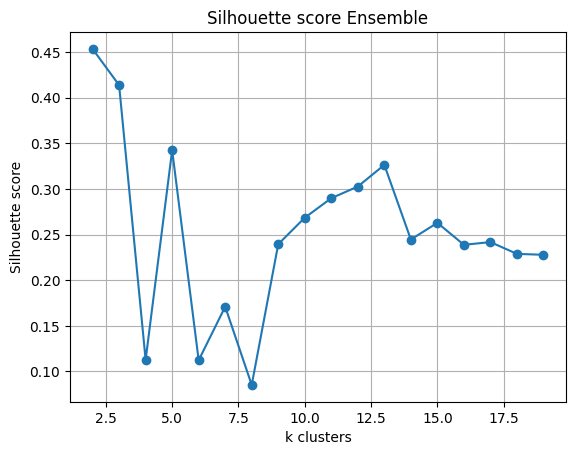

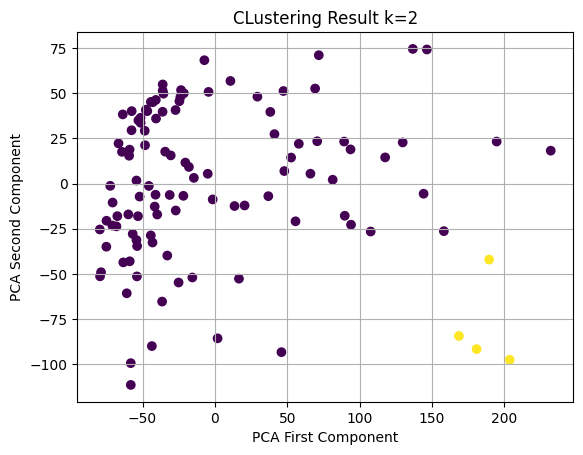

In [13]:
weights = [1, 1, 0]
ensemble_matrix = build_weighted_matrix(list_matrix, weights)

heatmap_ensemble(ensemble_matrix)
results = ensemble_result(ensemble_matrix)
silhouette_plot(results)

k=2
labels = ensemble_with_k(ensemble_matrix, k)
scatter_cluster(X_pca, labels, k)

Kết hợp kmeans và spectral clustering

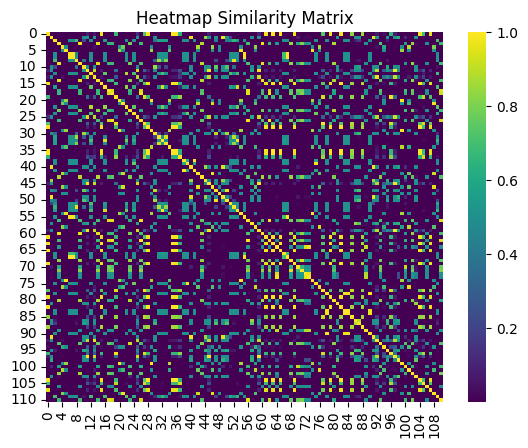

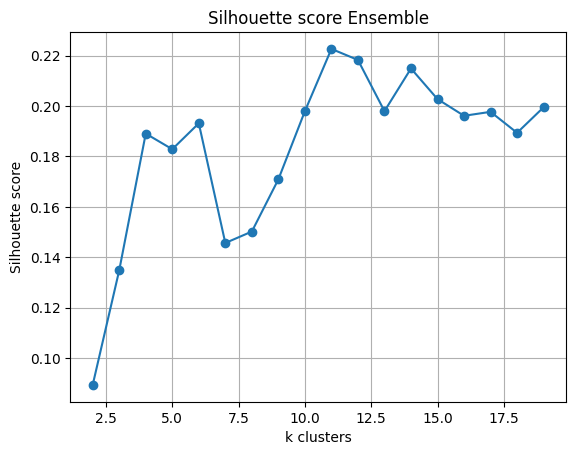

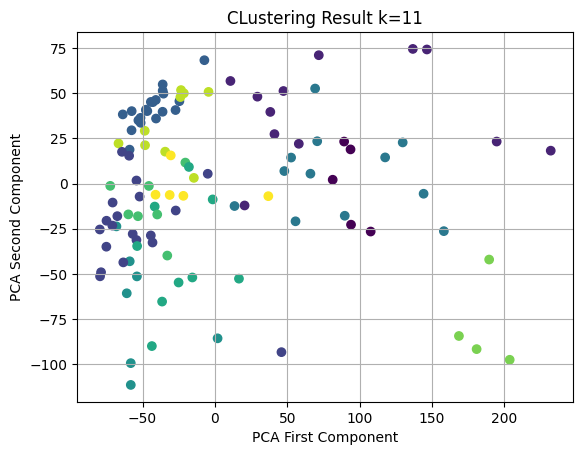

In [14]:
weights = [1, 0, 1]
ensemble_matrix = build_weighted_matrix(list_matrix, weights)

heatmap_ensemble(ensemble_matrix)
results = ensemble_result(ensemble_matrix)
silhouette_plot(results)

k=11
labels = ensemble_with_k(ensemble_matrix, k)
scatter_cluster(X_pca, labels, k)

Kết hợp agglomerative và spectral clustering

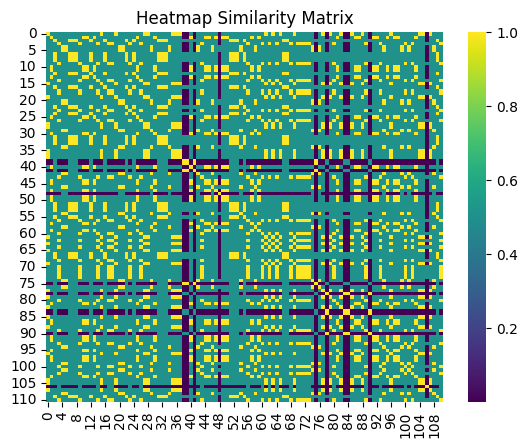

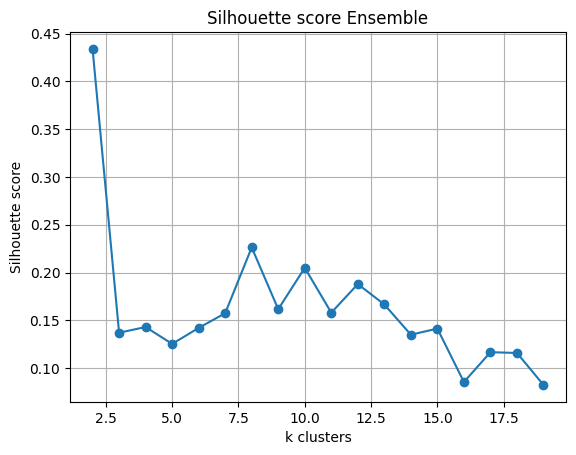

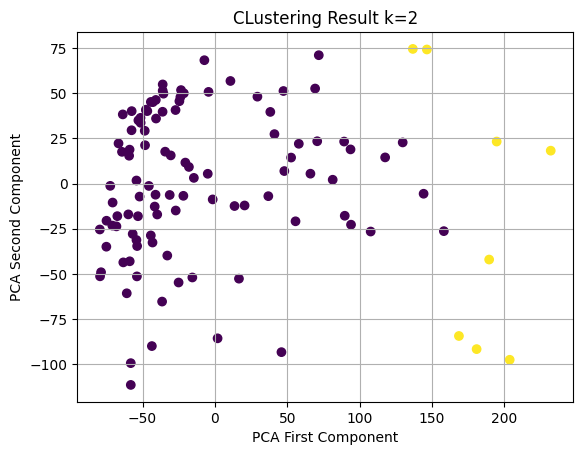

In [15]:
weights = [0, 1, 1]
ensemble_matrix = build_weighted_matrix(list_matrix, weights)

heatmap_ensemble(ensemble_matrix)
results = ensemble_result(ensemble_matrix)
silhouette_plot(results)

k=2
labels = ensemble_with_k(ensemble_matrix, k)
scatter_cluster(X_pca, labels, k)

Kết hợp nhiều kmeans

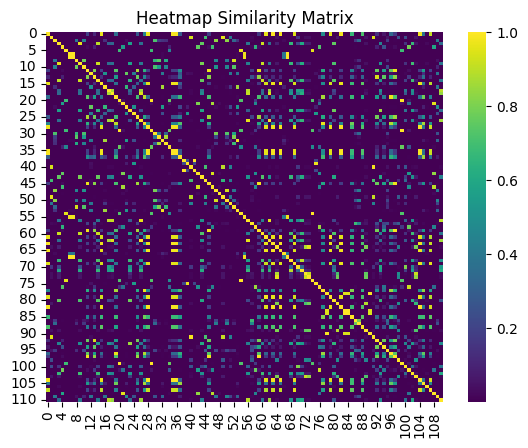

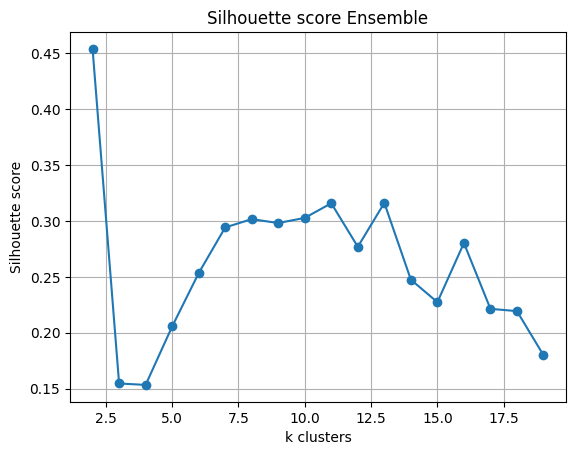

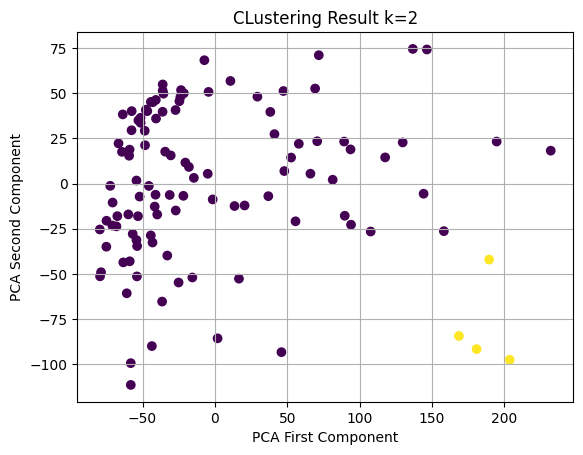

In [16]:
weights = [1, 0, 0]
ensemble_matrix = build_weighted_matrix(list_matrix, weights)

heatmap_ensemble(ensemble_matrix)
results = ensemble_result(ensemble_matrix)
silhouette_plot(results)

k=2
labels = ensemble_with_k(ensemble_matrix, k)
scatter_cluster(X_pca, labels, k)

Kết hợp có trọng số khác nhau

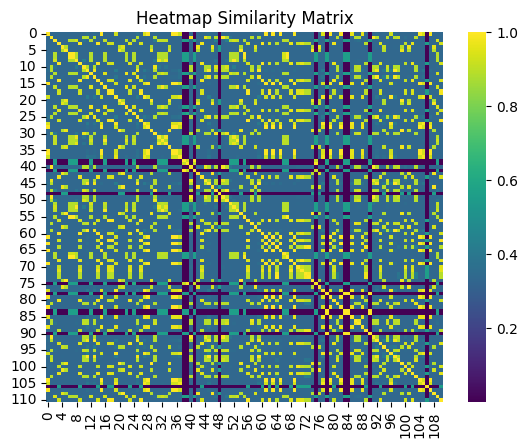

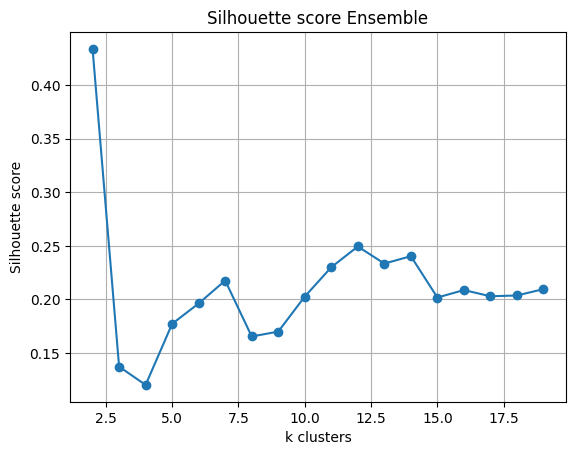

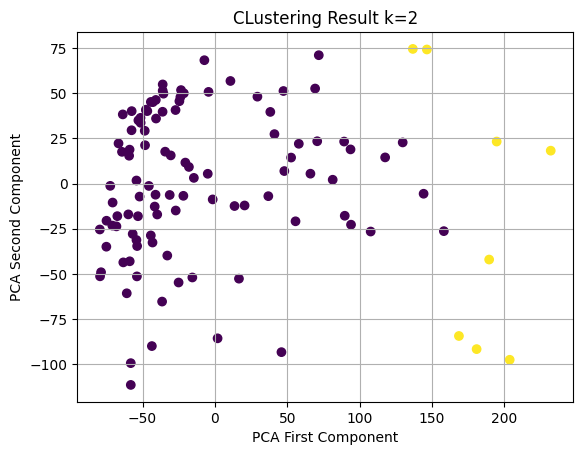

In [17]:
weights = [1, 3, 5]
ensemble_matrix = build_weighted_matrix(list_matrix, weights)

heatmap_ensemble(ensemble_matrix)
results = ensemble_result(ensemble_matrix)
silhouette_plot(results)

k=2
labels = ensemble_with_k(ensemble_matrix, k)
scatter_cluster(X_pca, labels, k)

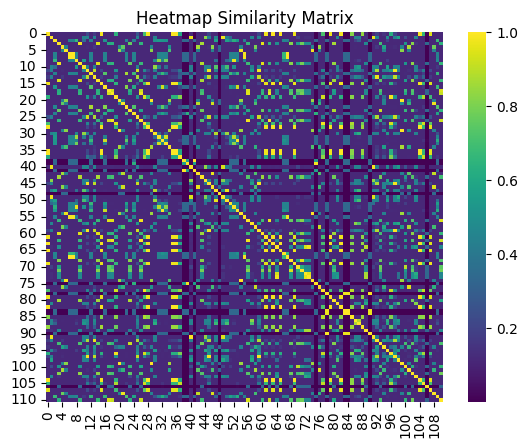

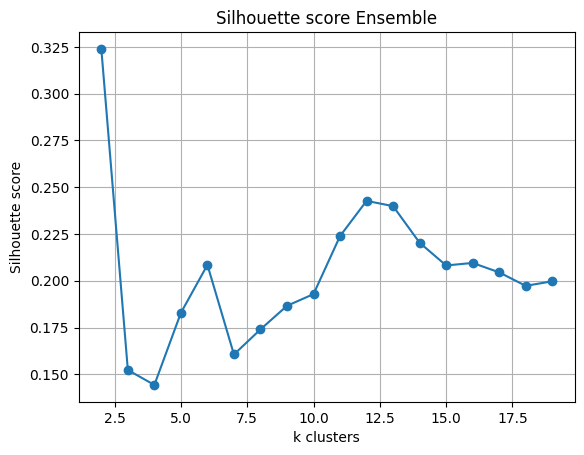

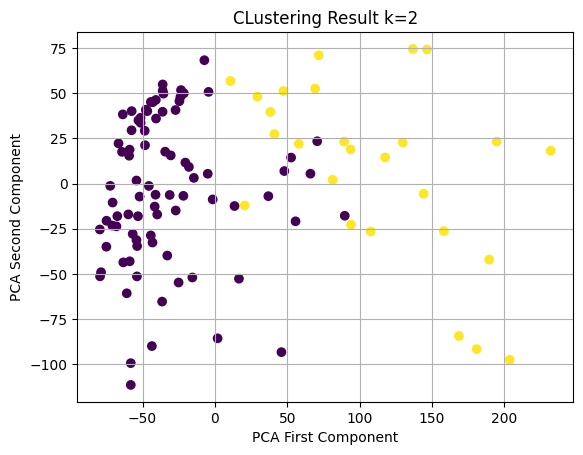

In [18]:
weights = [5, 1, 3]
ensemble_matrix = build_weighted_matrix(list_matrix, weights)

heatmap_ensemble(ensemble_matrix)
results = ensemble_result(ensemble_matrix)
silhouette_plot(results)

k=2
labels = ensemble_with_k(ensemble_matrix, k)
scatter_cluster(X_pca, labels, k)

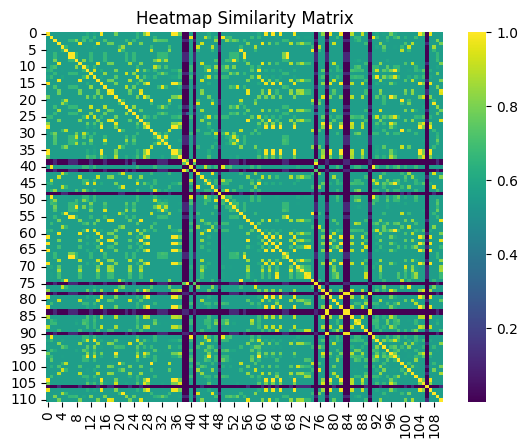

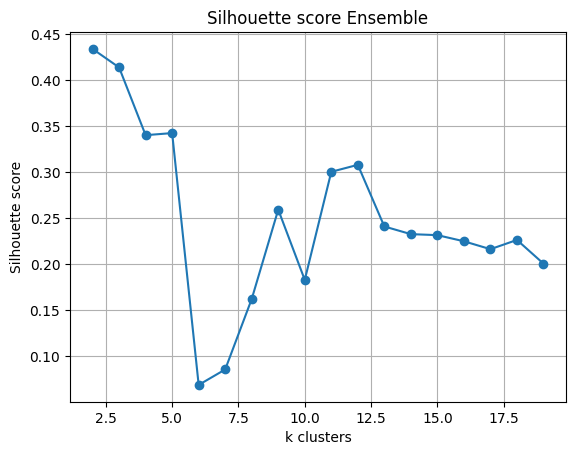

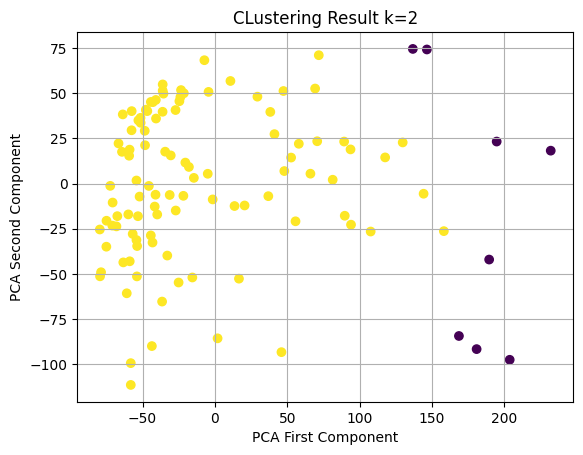

In [19]:
weights = [3, 5, 1]
ensemble_matrix = build_weighted_matrix(list_matrix, weights)

heatmap_ensemble(ensemble_matrix)
results = ensemble_result(ensemble_matrix)
silhouette_plot(results)

k=2
labels = ensemble_with_k(ensemble_matrix, k)
scatter_cluster(X_pca, labels, k)